# 08 — Modelado, Validación Temporal y Explicabilidad (V11)

**LEE** `dataset_v11_fe.csv` (+ `selected_features_v11.json` si existe).
**Anterior**: `07_feature_selection.ipynb`

## Contenido (nivel TFM)
1. Comparación de modelos con **nested CV** (5×3) y métrica **coste-sensible** (`scorer_academico`).
2. Búsqueda de hiperparámetros de XGBoost.
3. **Validación temporal**: entrenar en cohortes viejas (≤2011) y predecir las nuevas (≥2018).
   Responde la pregunta central: ¿un modelo entrenado en el pasado generaliza al futuro?
4. **Explicabilidad con SHAP**: qué materias / bloques / demografía impulsan el riesgo.

`Ejercicio` se EXCLUYE de las features del modelo (sería una fuga del año); se usa solo
para construir el split temporal.

In [1]:
import sys, json, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import (StratifiedKFold, cross_validate, train_test_split,
                                     RandomizedSearchCV, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format','{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted'); plt.rcParams['figure.dpi']=110

_cwd=Path('.').resolve()
BASE_DIR=next((p for p in [_cwd,_cwd.parent,_cwd.parent.parent] if (p/'data').exists()), _cwd.parent)
sys.path.append(str(BASE_DIR)); sys.path.append(str(BASE_DIR/'notebooks'))
from src.utils.metrics import scorer_academico
from preprocessing_pipeline import build_preprocessor

try:
    import shap
except ImportError:
    subprocess.run([sys.executable,'-m','pip','install','shap','-q']); import shap

SEED=42; CAT_ORDER=['buen_alumno','en_riesgo','con_dificultades']
CV=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
CV_INNER=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [2]:
# Cargar dataset (preferir el de feature engineering; si no, el preprocesado)
P_FE=BASE_DIR/'data'/'dataset_v11_fe.csv'; P_PRE=BASE_DIR/'data'/'dataset_v11_preproc.csv'
P_IN=P_FE if P_FE.exists() else P_PRE
df=pd.read_csv(P_IN)
df['categoria_target']=pd.Categorical(df['categoria_target'],categories=CAT_ORDER,ordered=True)
print(f'Dataset: {P_IN.name}  {df.shape}')

# Features: numéricas + categóricas que codifica el pipeline; EXCLUIR target y Ejercicio
EXCL={'target_num','categoria_target','GuidAlumno'}
NIVS=[c for c in ['NivEstudio','NivCurso'] if c in df.columns]
feat_cols=[c for c in df.columns if c not in EXCL and c!='Ejercicio']
# DECISIÓN V11: usar el CONJUNTO COMPLETO de features (explicabilidad por materia/bloque).
# El subconjunto de 07 (VIF + perm.importance) se reporta como análisis de parsimonia,
# pero el modelo final NO se poda: XGBoost tolera la multicolinealidad y así SHAP puede
# mostrar el peso de las materias individuales y los bloques temáticos.
print(f'Modelo sobre conjunto COMPLETO: {len(feat_cols)} features (incluye materias y bloques)')
X=df[feat_cols].copy(); y=df['target_num'].values; ejercicio=df['Ejercicio'].values
print(f'X: {X.shape}  |  target: {dict(zip(*np.unique(y,return_counts=True)))}')

# PROTOCOLO ANTI-LEAKAGE: apartar un TEST held-out (20%) que NO se toca en la CV ni en la
# búsqueda de hiperparámetros. Todo el desarrollo (CV = validación + tuning) usa solo el 80%
# de desarrollo; el test se evalúa UNA sola vez al final → estimación honesta de generalización.
X_dev,X_test,y_dev,y_test,ej_dev,ej_test = train_test_split(
    X, y, ejercicio, test_size=0.20, stratify=y, random_state=SEED)
print(f'Desarrollo (CV + tuning): {len(y_dev)}  |  TEST held-out (intacto hasta el final): {len(y_test)}')

Dataset: dataset_v11_fe.csv  (1205, 70)
Modelo sobre conjunto COMPLETO: 67 features (incluye materias y bloques)
X: (1205, 67)  |  target: {0: 867, 1: 213, 2: 125}
Desarrollo (CV + tuning): 964  |  TEST held-out (intacto hasta el final): 241


In [3]:
# Wrapper XGBoost con balanceo de clases por sample_weight
class BalancedXGB(XGBClassifier):
    def fit(self, X, y, **kw):
        sw=compute_sample_weight('balanced', y)
        return super().fit(X, y, sample_weight=sw, **kw)

def make_pipe(clf):
    # Opción B: XGBoost maneja NaN nativamente → NO imputar ni escalar (preserva la
    # señal de ausencia: 'este nivel no cursa esa materia'). RandomForest (sklearn) y
    # LogisticRegression NO toleran NaN → se imputa y escala como siempre.
    es_xgb = isinstance(clf, XGBClassifier)
    return Pipeline([('prep', build_preprocessor(X.columns.tolist(),
                      group_col='NivEstudio', nivcurso_col='NivCurso',
                      scale=not es_xgb, impute=not es_xgb)),
                     ('clf', clf)])

# Modelos REGULARIZADOS para reducir sobreajuste (RF con hojas grandes y profundidad
# limitada; XGBoost con regularización fuerte L1/L2 + gamma + submuestreo bajo).
modelos={
 'Dummy (most_frequent)': DummyClassifier(strategy='most_frequent'),
 'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5, random_state=SEED),
 'RandomForest': RandomForestClassifier(n_estimators=400, min_samples_leaf=15, max_depth=8,
                    max_features='sqrt', class_weight='balanced', random_state=SEED, n_jobs=-1),
 'XGBoost (balanced)': BalancedXGB(n_estimators=200, max_depth=2, learning_rate=0.05,
                    subsample=0.7, colsample_bytree=0.6, min_child_weight=10,
                    reg_lambda=10, reg_alpha=1, gamma=0.5, eval_metric='mlogloss',
                    random_state=SEED, n_jobs=-1, objective='multi:softprob', num_class=3),
}

## 1. Comparación de modelos — CV sobre DESARROLLO (coste-sensible: `score_academico`)

TRAIN vs TEST (CV 5-fold sobre DESARROLLO 80%) — métrica = score_academico (la brecha = sobreajuste):
               modelo  acad_train  acad_test  gap_acad  acc_train  acc_test  gap_acc
   XGBoost (balanced)       0.972      0.958     0.014      0.851     0.802    0.049
         RandomForest       0.961      0.956     0.006      0.792     0.771    0.021
   LogisticRegression       0.967      0.944     0.022      0.848     0.789    0.058
Dummy (most_frequent)       0.808      0.808     0.000      0.720     0.720    0.000


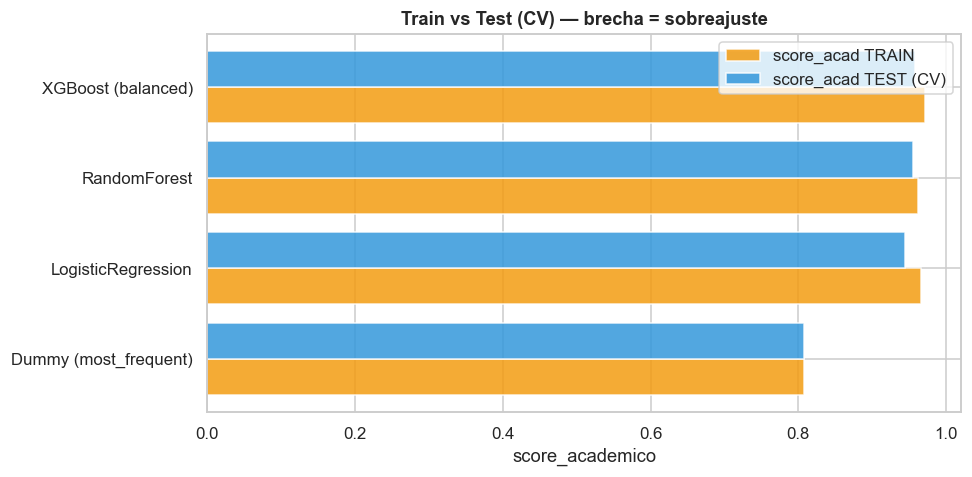


Brecha grande (train >> test) = sobreajuste.


In [4]:
# Métrica optimizada: score_academico (coste-sensible). Acompañamos con accuracy. Sin F1.
scoring={'score_acad':scorer_academico,'accuracy':'accuracy'}
filas=[]
for nombre,clf in modelos.items():
    cv=cross_validate(make_pipe(clf), X_dev, y_dev, cv=CV, scoring=scoring, n_jobs=-1, return_train_score=True)
    filas.append({'modelo':nombre,
        'acad_train':cv['train_score_acad'].mean(), 'acad_test':cv['test_score_acad'].mean(),
        'gap_acad':cv['train_score_acad'].mean()-cv['test_score_acad'].mean(),
        'acad_test_std':cv['test_score_acad'].std(),
        'acc_train':cv['train_accuracy'].mean(), 'acc_test':cv['test_accuracy'].mean(),
        'gap_acc':cv['train_accuracy'].mean()-cv['test_accuracy'].mean()})
res=pd.DataFrame(filas).sort_values('acad_test', ascending=False)
print('TRAIN vs TEST (CV 5-fold sobre DESARROLLO 80%) — métrica = score_academico (la brecha = sobreajuste):')
print(res[['modelo','acad_train','acad_test','gap_acad','acc_train','acc_test','gap_acc']].round(3).to_string(index=False))

fig,ax=plt.subplots(figsize=(9,4.5))
yp=np.arange(len(res))
ax.barh(yp+0.2, res['acad_train'], height=0.4, color='#f39c12', alpha=.85, label='score_acad TRAIN')
ax.barh(yp-0.2, res['acad_test'],  height=0.4, color='#3498db', alpha=.85, label='score_acad TEST (CV)')
ax.set_yticks(yp); ax.set_yticklabels(res['modelo']); ax.invert_yaxis()
ax.set_xlabel('score_academico'); ax.set_title('Train vs Test (CV) — brecha = sobreajuste', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print('\nBrecha grande (train >> test) = sobreajuste.')

## 2. Búsqueda de hiperparámetros — XGBoost

In [5]:
# Espacio sesgado a REGULARIZACIÓN (árboles poco profundos, hojas con muchas
# observaciones, L1/L2 y gamma altos, submuestreo) → reduce la brecha train-test.
espacio={'clf__max_depth':[1,2,3],'clf__learning_rate':[0.02,0.05,0.08],
 'clf__n_estimators':[100,200,300],'clf__subsample':[0.6,0.7,0.8],
 'clf__colsample_bytree':[0.4,0.5,0.6],'clf__min_child_weight':[5,10,20],
 'clf__reg_lambda':[5,10,20,50],'clf__reg_alpha':[0,1,5],'clf__gamma':[0,0.5,1,2]}
base=BalancedXGB(eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
                 objective='multi:softprob', num_class=3)
rs=RandomizedSearchCV(make_pipe(base), {**espacio}, n_iter=30, cv=CV_INNER,
     scoring=scorer_academico, random_state=SEED, n_jobs=-1, verbose=0)
rs.fit(X_dev,y_dev)   # tuning SOLO sobre desarrollo; el test held-out queda intacto
print(f'Mejor score_acad (CV interna sobre desarrollo): {rs.best_score_:.4f}')
print('Mejores hiperparámetros:')
for k,v in rs.best_params_.items(): print(f'  {k.replace("clf__","")}: {v}')
best_pipe=rs.best_estimator_

Mejor score_acad (CV interna sobre desarrollo): 0.9601
Mejores hiperparámetros:
  subsample: 0.7
  reg_lambda: 20
  reg_alpha: 1
  n_estimators: 100
  min_child_weight: 10
  max_depth: 2
  learning_rate: 0.08
  gamma: 0.5
  colsample_bytree: 0.4


## 2b. Evaluación FINAL en el TEST held-out (estimación honesta)

El 20% apartado al inicio **no participó** en la CV ni en la búsqueda de hiperparámetros.
Esta es la estimación insesgada de cómo generaliza el modelo elegido a datos no vistos.

XGBoost regularizado — DESARROLLO (in-sample) vs TEST held-out (nunca tocado):
  score_acad: dev 0.964 | TEST 0.956
  accuracy  : dev 0.821 | TEST 0.797


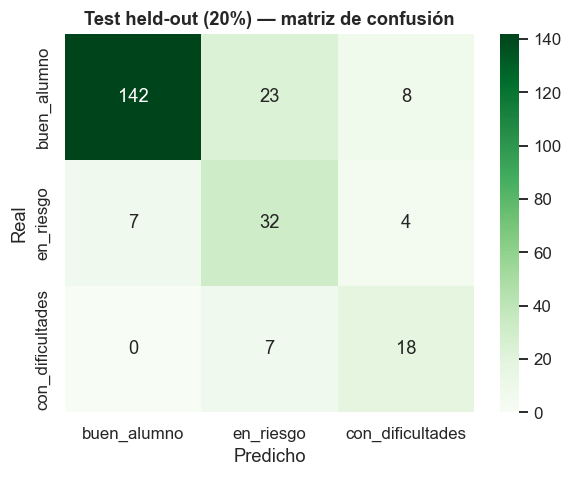

In [6]:
# best_pipe ya viene reajustado en X_dev por RandomizedSearchCV (refit=True). Evaluamos en TEST.
print('XGBoost regularizado — DESARROLLO (in-sample) vs TEST held-out (nunca tocado):')
print(f'  score_acad: dev {scorer_academico(best_pipe,X_dev,y_dev):.3f} | TEST {scorer_academico(best_pipe,X_test,y_test):.3f}')
print(f'  accuracy  : dev {accuracy_score(y_dev,best_pipe.predict(X_dev)):.3f} | TEST {accuracy_score(y_test,best_pipe.predict(X_test)):.3f}')
cm_t=confusion_matrix(y_test, best_pipe.predict(X_test))
fig,ax=plt.subplots(figsize=(5.5,4.5))
sns.heatmap(cm_t,annot=True,fmt='d',cmap='Greens',xticklabels=CAT_ORDER,yticklabels=CAT_ORDER,ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Test held-out (20%) — matriz de confusión', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Validación temporal — train pasado (≤2011), test futuro (≥2018)

La pregunta central del TFM: un modelo entrenado con cohortes históricas, ¿predice cohortes
futuras? Es una prueba mucho más exigente (y realista) que el CV aleatorio.

Train (<=2011): 883  |  Test (>=2018): 322


VALIDACIÓN TEMPORAL — TRAIN (≤2011) vs TEST (≥2018):
  TRAIN: score_acad 0.979 | accuracy 0.870
  TEST : score_acad 0.834 | accuracy 0.568
  BRECHA train-test (score_acad): 0.144

Accuracy del test temporal POR NIVEL (diagnóstico tiempo vs nivel):
  Bachillerato   n=  13  accuracy 0.615
  ESO            n= 134  accuracy 0.440
  Primaria       n= 175  accuracy 0.663
Composición de nivel:
  TRAIN (<=2011): {'Primaria': 599, 'ESO': 211, 'Bachillerato': 73}
  TEST  (>=2018): {'Primaria': 175, 'ESO': 134, 'Bachillerato': 13}


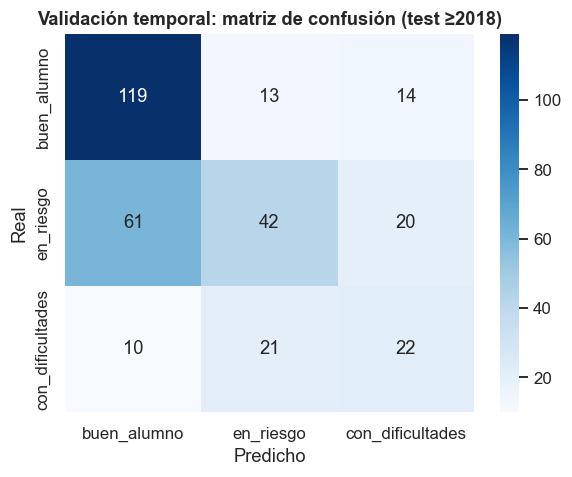

In [7]:
mask_tr=ejercicio<=2011; mask_te=ejercicio>=2018
Xtr,Xte=X[mask_tr],X[mask_te]; ytr,yte=y[mask_tr],y[mask_te]
print(f'Train (<=2011): {mask_tr.sum()}  |  Test (>=2018): {mask_te.sum()}')

# Modelo temporal: mismos hiperparámetros del mejor XGB
temp_pipe=make_pipe(BalancedXGB(**{k.replace('clf__',''):v for k,v in rs.best_params_.items()},
                    eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
                    objective='multi:softprob', num_class=3))
temp_pipe.fit(Xtr,ytr)
pred_tr=temp_pipe.predict(Xtr); pred_te=temp_pipe.predict(Xte)
# Comparación TRAIN (in-sample, <=2011) vs TEST (out-of-sample temporal, >=2018)
acad_tr=scorer_academico(temp_pipe,Xtr,ytr); acad_te=scorer_academico(temp_pipe,Xte,yte)
print('VALIDACIÓN TEMPORAL — TRAIN (≤2011) vs TEST (≥2018):')
print(f'  TRAIN: score_acad {acad_tr:.3f} | accuracy {accuracy_score(ytr,pred_tr):.3f}')
print(f'  TEST : score_acad {acad_te:.3f} | accuracy {accuracy_score(yte,pred_te):.3f}')
print(f'  BRECHA train-test (score_acad): {acad_tr-acad_te:.3f}')
# Desglose del test temporal POR NIVEL → ¿la caída es por cambio de composición de nivel?
te_niv=pd.DataFrame({'nivel':df.loc[mask_te,'NivEstudio'].values,'y':yte,'pred':pred_te})
print('\nAccuracy del test temporal POR NIVEL (diagnóstico tiempo vs nivel):')
for niv,g in te_niv.groupby('nivel'):
    print(f'  {niv:<14} n={len(g):>4}  accuracy {accuracy_score(g.y,g.pred):.3f}')
print('Composición de nivel:')
print('  TRAIN (<=2011):', pd.Series(df.loc[mask_tr,'NivEstudio'].values).value_counts().to_dict())
print('  TEST  (>=2018):', pd.Series(df.loc[mask_te,'NivEstudio'].values).value_counts().to_dict())
cm=confusion_matrix(yte,pred_te)
fig,ax=plt.subplots(figsize=(5.5,4.5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CAT_ORDER,yticklabels=CAT_ORDER,ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Validación temporal: matriz de confusión (test ≥2018)', fontweight='bold')
plt.tight_layout(); plt.show()

### 3b. ¿Por qué falla la transferencia temporal en ESO?

El desglose por nivel mostró que la caída se concentra en ESO (Primaria y Bachillerato
transfieren bien). Investigamos si es **deriva real** del cohorte —el ESO de 2019 tiene
distinta proporción de riesgo o distinto nivel de notas que el de 2010— o si ESO es
simplemente más difícil de predecir.

In [8]:
# (a) Confusión SOLO del ESO en el test temporal: ¿en qué se equivoca?
eso_te=(df.loc[mask_te,'NivEstudio'].values=='ESO')
print('ESO en test temporal (>=2018): n =', int(eso_te.sum()))
print('Matriz de confusión ESO (filas=real, columnas=predicho):')
print(pd.DataFrame(confusion_matrix(yte[eso_te], pred_te[eso_te], labels=[0,1,2]),
      index=[f'real_{c}' for c in CAT_ORDER], columns=[f'pred_{c}' for c in CAT_ORDER]).to_string())

# (b) Comparar el cohorte ESO de 2010 (train) vs 2019 (test): clases + nivel de notas 1EV
print('\nComparación del cohorte ESO — 2010 (train) vs 2019 (test):')
for anio in [2010, 2019]:
    sub=df[(df['Ejercicio']==anio)&(df['NivEstudio']=='ESO')]
    if len(sub)==0: continue
    dist=sub['categoria_target'].value_counts(normalize=True).reindex(CAT_ORDER).round(3).to_dict()
    nm=sub['nota_media_1ev'].mean() if 'nota_media_1ev' in sub.columns else float('nan')
    print(f'  {anio} ESO (n={len(sub):>3}): clases={dist} | nota_media_1ev={nm:.2f}')

ESO en test temporal (>=2018): n = 134
Matriz de confusión ESO (filas=real, columnas=predicho):
                       pred_buen_alumno  pred_en_riesgo  pred_con_dificultades
real_buen_alumno                     10               5                      7
real_en_riesgo                       28              29                     11
real_con_dificultades                 4              20                     20

Comparación del cohorte ESO — 2010 (train) vs 2019 (test):
  2010 ESO (n=211): clases={'buen_alumno': 0.474, 'en_riesgo': 0.27, 'con_dificultades': 0.256} | nota_media_1ev=6.43
  2019 ESO (n=130): clases={'buen_alumno': 0.138, 'en_riesgo': 0.523, 'con_dificultades': 0.338} | nota_media_1ev=5.40


## 4. Explicabilidad con SHAP

Sobre el mejor XGBoost (ajustado en el conjunto de desarrollo). SHAP descompone cada predicción en la contribución de cada feature → qué materia/área/demografía dispara el riesgo.

Top 20 features (SHAP (media |valor SHAP|)):
pct_aprobado_1ev          0.237
n_suspensos_1ev           0.134
pct_asignaturas__SOC      0.123
mat__Lengua_Castellana    0.090
fe_dispersion_comp        0.076
nota_min__STEM            0.074
nota_media__STEM          0.074
nota_min__SOC             0.070
fe_riesgo_intenso         0.068
niv_eso                   0.068
mat__Ciencias             0.066
pct_asignaturas__LING     0.056
nota_media_1ev            0.054
no_justificadas_1ev_log   0.052
nota_media__SOC           0.050
fe_faltas_por_asig        0.048
nota_min_1ev              0.048
mat__Tecnologia           0.043
n_asignaturas_1ev         0.040
mes_nacimiento            0.034


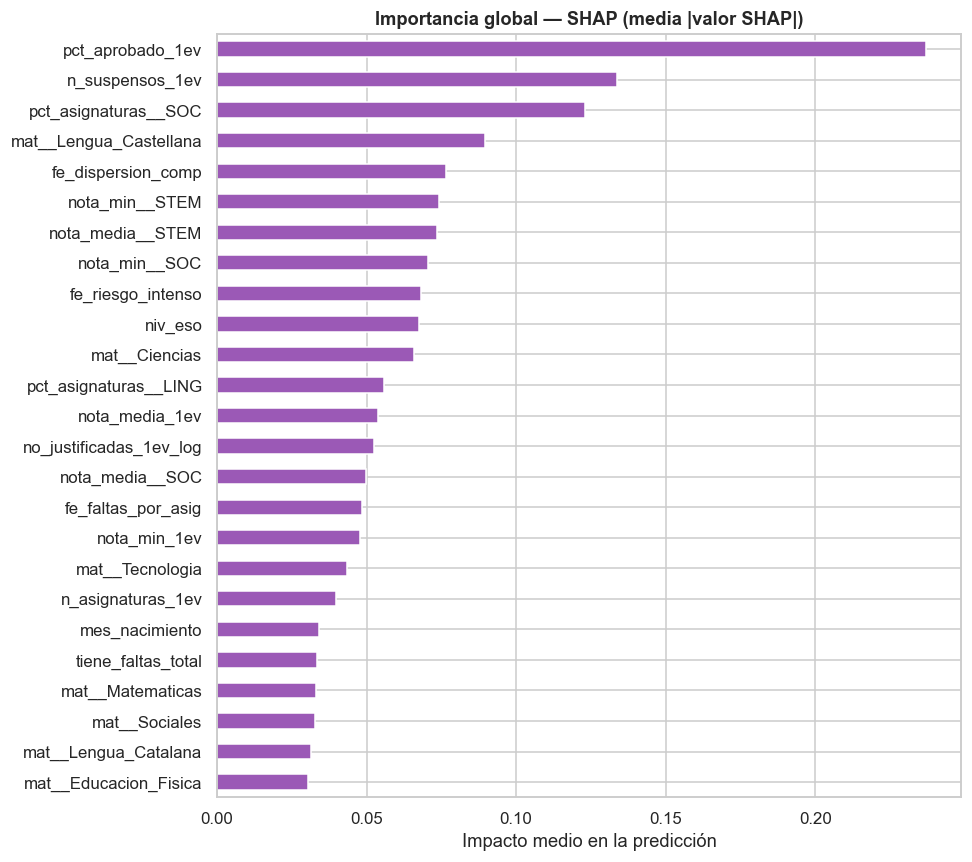

In [9]:
best_pipe.fit(X_dev,y_dev)
prep=best_pipe.named_steps['prep']; clf=best_pipe.named_steps['clf']
Xt=prep.transform(X_dev)
if not isinstance(Xt,pd.DataFrame):
    Xt=pd.DataFrame(np.asarray(Xt), columns=[f'f{i}' for i in range(np.asarray(Xt).shape[1])])
nf=Xt.shape[1]
explainer=shap.TreeExplainer(clf)
sv=explainer.shap_values(Xt)

def shap_global(sv, nf):
    # Devuelve importancia global (longitud = nº features), robusta a list/2D/3D
    if isinstance(sv, list):
        return np.mean([np.abs(np.asarray(s)).mean(0) for s in sv], axis=0)
    a=np.abs(np.asarray(sv))
    if a.ndim==2: return a.mean(0)
    feat_ax=next((ax for ax in range(a.ndim) if a.shape[ax]==nf), a.ndim-1)
    otros=tuple(ax for ax in range(a.ndim) if ax!=feat_ax)
    return a.mean(axis=otros)

try:
    glob=shap_global(sv, nf)
    imp=pd.Series(glob, index=Xt.columns).sort_values(ascending=False)
    fuente='SHAP (media |valor SHAP|)'
except Exception as e:
    print('SHAP global fallo, uso feature_importances_:', e)
    imp=pd.Series(clf.feature_importances_, index=Xt.columns).sort_values(ascending=False)
    fuente='XGBoost feature_importances_'
print(f'Top 20 features ({fuente}):'); print(imp.head(20).to_string())
fig,ax=plt.subplots(figsize=(9,8))
imp.head(25).iloc[::-1].plot(kind='barh', color='#9b59b6', ax=ax)
ax.set_title(f'Importancia global — {fuente}', fontweight='bold')
ax.set_xlabel('Impacto medio en la predicción'); plt.tight_layout(); plt.show()

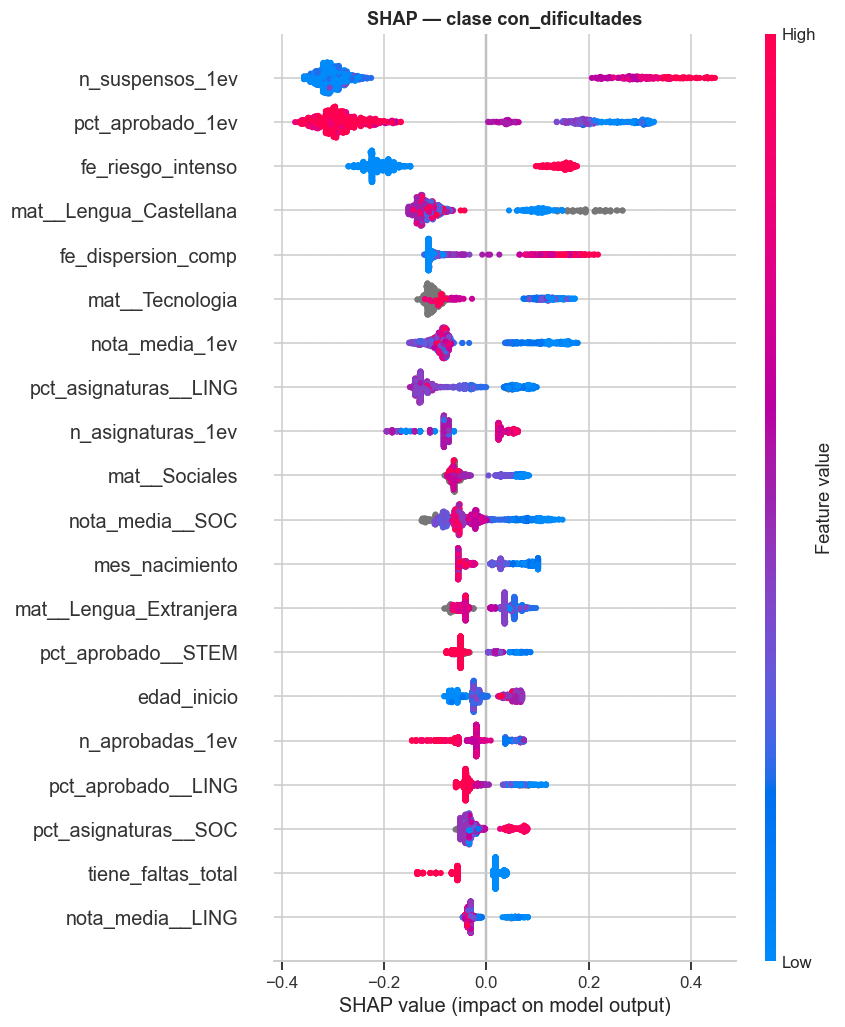

In [10]:
# SHAP summary plot (clase con_dificultades = la de mayor coste pedagógico)
try:
    idx_dif=CAT_ORDER.index('con_dificultades')
    if isinstance(sv,list):
        sv_dif=np.asarray(sv[idx_dif])
    else:
        a=np.asarray(sv)
        if a.ndim==3:
            if a.shape[-1]==len(CAT_ORDER): sv_dif=a[:,:,idx_dif]
            elif a.shape[0]==len(CAT_ORDER): sv_dif=a[idx_dif]
            else: sv_dif=a.take(idx_dif, axis=-1)
        else: sv_dif=a
    shap.summary_plot(sv_dif, Xt, show=False, max_display=20)
    plt.title('SHAP — clase con_dificultades', fontweight='bold'); plt.tight_layout(); plt.show()
except Exception as e:
    print('summary_plot omitido:', e)

## 5. Conclusiones

- **Mejor modelo**: XGBoost balanceado con búsqueda de hiperparámetros (ver §1-2).
- **Validación temporal (§3)**: cuantifica la generalización a cohortes futuras — la métrica
  honesta para un sistema de alerta temprana real.
- **Explicabilidad (§4)**: SHAP identifica las materias/áreas/variables demográficas que más
  pesan en el riesgo, base para la interpretación pedagógica de la memoria.